In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

## Load & Explore Data

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
print("Data Types")
print(df.dtypes)
print("\nDescriptive Statistics")
print(df.describe())
print("\nMissing Values")
print(df.isnull().sum())

Data Types
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Descriptive Statistics
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000

Missing Values
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
r

## Data Cleaning

In [3]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("Duplicates Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


## Outlier Removal

In [4]:
num_cols = ["math score", "reading score", "writing score"]
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df[col] >= lower) & (df[col] <= upper)]

## Visualizations

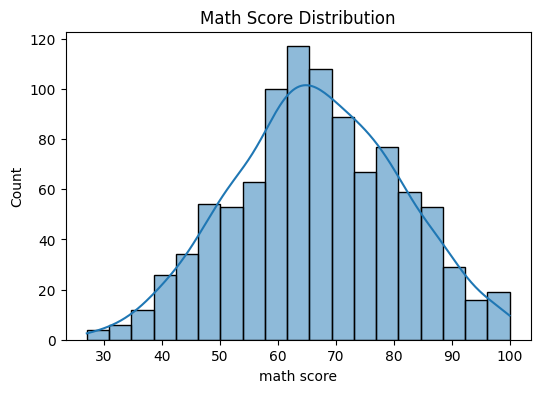

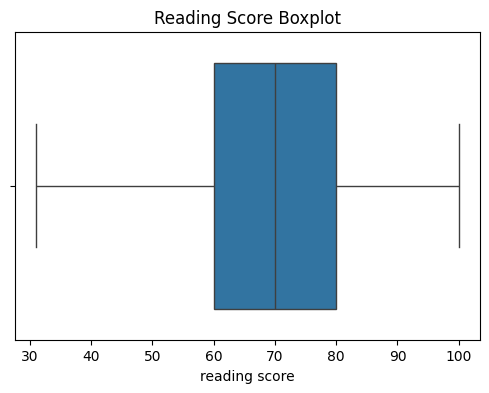

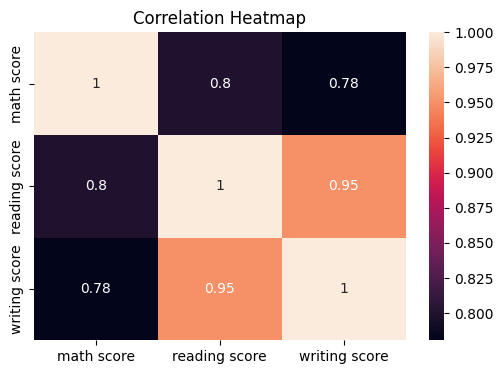

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["math score"], kde=True)
plt.title("Math Score Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["reading score"])
plt.title("Reading Score Boxplot")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df[num_cols].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering & Encoding

In [6]:
df["final_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3
df["pass_fail"] = np.where(df["final_score"] >= 40, 1, 0)

le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

## Regression Models

In [7]:
X_reg = df.drop(["final_score", "pass_fail"], axis=1)
y_reg = df["final_score"]

scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
pred_lr = lr.predict(X_test_reg)

rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
pred_rf = rf_reg.predict(X_test_reg)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test_reg, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_lr)))
print("R2:", r2_score(y_test_reg, pred_lr))

print("\nRandom Forest Regressor")
print("MAE:", mean_absolute_error(y_test_reg, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, pred_rf)))
print("R2:", r2_score(y_test_reg, pred_rf))

Linear Regression
MAE: 7.787261295956654e-15
RMSE: 1.069992612370206e-14
R2: 1.0

Random Forest Regressor
MAE: 0.4710269360269335
RMSE: 0.7427780610895239
R2: 0.9970010887048154


## Classification Models

In [8]:
X_cls = df.drop(["pass_fail", "final_score"], axis=1)
y_cls = df["pass_fail"]

X_cls_scaled = scaler.fit_transform(X_cls)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train_cls, y_train_cls)
pred_log = log_model.predict(X_test_cls)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_cls, y_train_cls)
pred_dt = dt_model.predict(X_test_cls)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_cls, y_train_cls)
pred_rf_cls = rf_model.predict(X_test_cls)

print("Logistic Regression Accuracy:", accuracy_score(y_test_cls, pred_log))
print(classification_report(y_test_cls, pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test_cls, pred_dt))
print(classification_report(y_test_cls, pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test_cls, pred_rf_cls))
print(classification_report(y_test_cls, pred_rf_cls))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       195

    accuracy                           1.00       198
   macro avg       1.00      1.00      1.00       198
weighted avg       1.00      1.00      1.00       198

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       195

    accuracy                           1.00       198
   macro avg       1.00      1.00      1.00       198
weighted avg       1.00      1.00      1.00       198

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00       195

    accuracy                           1.00       198
   macro avg       1.00      1.00     

## Model Comparison

In [9]:
comparison_reg = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "R2 Score": [r2_score(y_test_reg, pred_lr), r2_score(y_test_reg, pred_rf)]
})

comparison_cls = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test_cls, pred_log), accuracy_score(y_test_cls, pred_dt), accuracy_score(y_test_cls, pred_rf_cls)]
})

print("Regression Model Comparison")
print(comparison_reg)
print("\nClassification Model Comparison")
print(comparison_cls)

Regression Model Comparison
                     Model  R2 Score
0        Linear Regression  1.000000
1  Random Forest Regressor  0.997001

Classification Model Comparison
                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0
